# **Preparación de los datos**

## Extracción

In [48]:
import pandas as pd
import numpy as np
data = pd.read_csv('TelecomX_data.csv')
data.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,daily_accounts
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## Correlación de variables numéricas

In [49]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7043 non-null   str    
 1   churn                      7043 non-null   str    
 2   customer_gender            7043 non-null   str    
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   str    
 5   customer_dependents        7043 non-null   str    
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   str    
 8   phone_multiplelines        7043 non-null   str    
 9   internet_internetservice   7043 non-null   str    
 10  internet_onlinesecurity    7043 non-null   str    
 11  internet_onlinebackup      7043 non-null   str    
 12  internet_deviceprotection  7043 non-null   str    
 13  internet_techsupport       7043 non-null   str    
 14  int

In [50]:
variables_numericas = data.select_dtypes( include = ['int64', 'float64'])
matriz_corr = variables_numericas.corr()
matriz_corr

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,daily_accounts
customer_seniorcitizen,1.000000,0.016567,0.220173,0.103006,0.220173
customer_tenure,0.016567,1.000000,0.247900,0.826178,0.247900
account_charges_monthly,0.220173,0.247900,1.000000,0.651174,1.000000
account_charges_total,0.103006,0.826178,0.651174,1.000000,0.651174
daily_accounts,0.220173,0.247900,1.000000,0.651174,1.000000


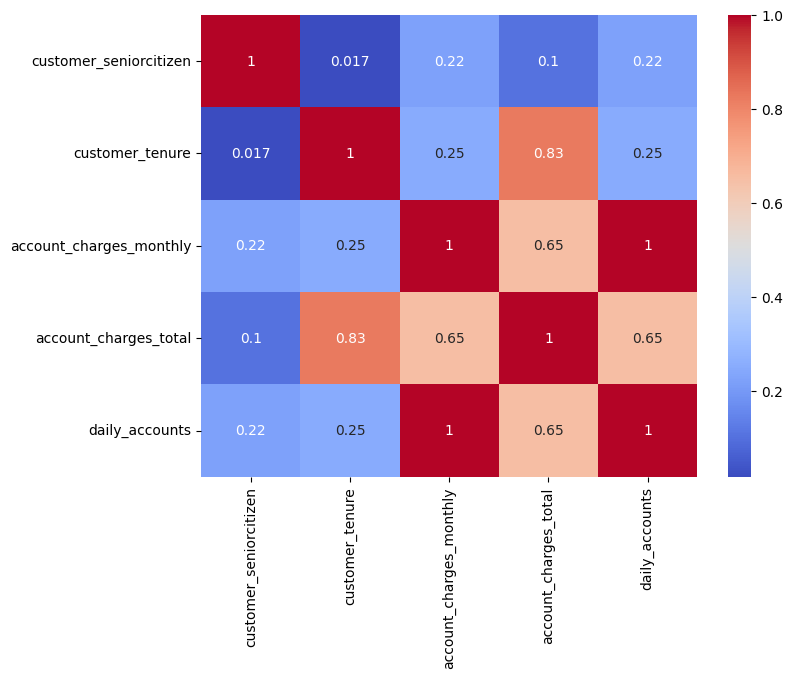

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    variables_numericas.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

## Correlación de variables categóricas

In [52]:
data.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'daily_accounts'],
      dtype='str')

In [53]:
variables_categoricas = data.select_dtypes(include=['object']).columns
variables_categoricas = variables_categoricas.drop('churn')

#Tabla de proporción por categoria
for col in variables_categoricas:
    print(f'\n🔍 Analisis de variable: {col}')
    display(pd.crosstab(data[col], data['churn'], normalize = 'index') * 100)


🔍 Analisis de variable: customerid


C:\Users\andre\AppData\Local\Temp\ipykernel_17424\1159389914.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = data.select_dtypes(include=['object']).columns


churn,No,Yes
customerid,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0



🔍 Analisis de variable: customer_gender


churn,No,Yes
customer_gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


...

churn,No,Yes
account_contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



🔍 Analisis de variable: account_paperlessbilling


churn,No,Yes
account_paperlessbilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



🔍 Analisis de variable: account_paymentmethod


churn,No,Yes
account_paymentmethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Eliminación de columnas irrelevantes

Se elimina la variable daily_accounts debido a su correlación perfecta (r=1.0) con account_charges_monthly, evitando redundancia y multicolinealidad en el modelo. También se elimina customerid puesto que sólo es un identificador del cliente. De igual manera, account_charges_total debido a su correlación (0.65) con account_charges_monthly pues se piensa trabajar regresión lineal.

In [54]:
data.drop(columns = ['customerid', 'daily_accounts', 'account_charges_total'], inplace = True)

## Encoding

In [55]:
X = data.drop('churn', axis = 1)
y = data['churn']

In [56]:
X

,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [57]:
y

0        No
1        No
2       Yes
3       Yes
4       Yes
       ... 
7038     No
7039    Yes
7040     No
7041     No
7042     No
Name: churn, Length: 7043, dtype: str

In [58]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y,  random_state = 5)

### Transformando las variables categóricas

In [59]:
import sklearn 
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [60]:
variables_categoricas = ['customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       ]

In [61]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    (variables_categoricas)
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

X_train_encoded = one_hot.fit_transform(X_train)
X_test_encoded = one_hot.transform(X_test)

column_names = one_hot.get_feature_names_out()

X_train_encoded = pd.DataFrame(X_train_encoded, columns=column_names)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=column_names)

c:\Users\andre\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


### Tranformando la variable respuesta

In [62]:
from sklearn.preprocessing import LabelEncoder

In [63]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

## Verificación de la Proporción de Cancelación (Churn)

In [64]:
data['churn'].value_counts(normalize = True).round(2)

churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64

## Desbalanceo de clases

In [65]:
pd.Series(y_train).value_counts(normalize=True)

0    0.73457
1    0.26543
Name: proportion, dtype: float64

In [66]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_encoded, y_train)

## Normalización o estandarización 

El objetivo de la normalización o estandarización es transformar las características de cada variable para que estén en una escala similar. Esto ayuda a que los modelos converjan más rápido durante el entrenamiento, ayuda a inferir mejores predicciones y ayuda a que el modelo aprenda mejor los pesos adecuados para cada atributo.

Algunos modelos como la regresión logística o el kNN son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_res)

X_train_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test_encoded)

# **Correlación y selección de variables**

## Análisis de correlación

In [68]:
# La matriz de las variables numéricas se hizo anteriormente

In [69]:
variables_categoricas_corr= X_test_encoded.corr()
variables_categoricas_corr.head()

,onehotencoder__customer_gender_Male,onehotencoder__customer_seniorcitizen_1,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phoneservice_Yes,onehotencoder__phone_multiplelines_No,onehotencoder__phone_multiplelines_No phone service,onehotencoder__phone_multiplelines_Yes,onehotencoder__internet_internetservice_DSL,onehotencoder__internet_internetservice_Fiber optic,...,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperlessbilling_Yes,onehotencoder__account_paymentmethod_Bank transfer (automatic),onehotencoder__account_paymentmethod_Credit card (automatic),onehotencoder__account_paymentmethod_Electronic check,onehotencoder__account_paymentmethod_Mailed check,remainder__customer_tenure,remainder__account_charges_monthly
onehotencoder__customer_gender_Male,1.000000,0.008892,-0.011950,0.016720,-0.049933,-0.024483,0.049933,-0.005720,-0.001454,-0.006742,...,0.015564,-0.017713,-0.001012,-0.028956,-0.068843,0.001469,0.033296,0.028278,-0.016403,-0.023390
onehotencoder__customer_seniorcitizen_1,0.008892,1.000000,0.023628,-0.233306,0.018292,-0.141596,-0.018292,0.155160,-0.111498,0.259678,...,0.138880,-0.019253,-0.142271,0.146986,0.009658,-0.036960,0.190059,-0.184735,0.034307,0.227201
onehotencoder__customer_partner_Yes,-0.011950,0.023628,1.000000,0.481012,0.057429,-0.130252,-0.057429,0.167619,-0.013858,0.016524,...,-0.253857,0.031967,0.263152,0.001092,0.063780,0.093446,-0.044485,-0.102025,0.365332,0.120959
onehotencoder__customer_dependents_Yes,0.016720,-0.233306,0.481012,1.000000,-0.005866,0.011313,0.005866,-0.015096,0.056655,-0.169562,...,-0.231337,0.020432,0.248159,-0.153954,0.064140,0.051685,-0.156247,0.061678,0.150873,-0.111624
onehotencoder__phone_phoneservice_Yes,-0.049933,0.018292,0.057429,-0.005866,1.000000,0.328355,-1.000000,0.279203,-0.452084,0.288818,...,-0.022225,0.027397,-0.000576,0.031227,0.025214,-0.015685,0.022497,-0.034311,0.057175,0.258763


# **Análisis dirigido**

## Tiempo de contrato vs Churn

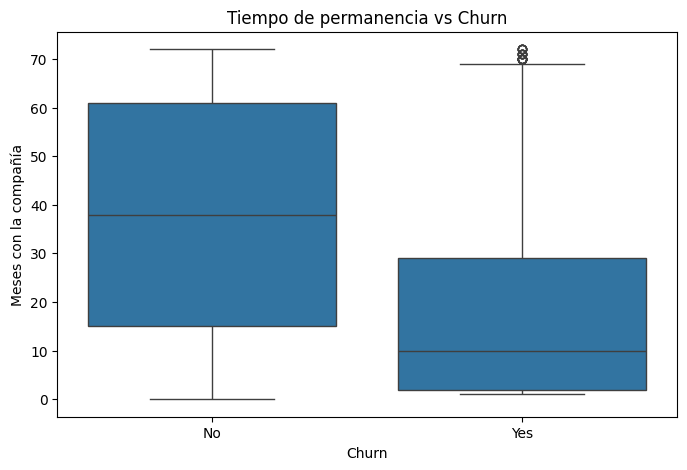

In [70]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='customer_tenure', data=data)

plt.title('Tiempo de permanencia vs Churn')
plt.xlabel('Churn')
plt.ylabel('Meses con la compañía')

plt.show()

## Gasto mensual vs Churn

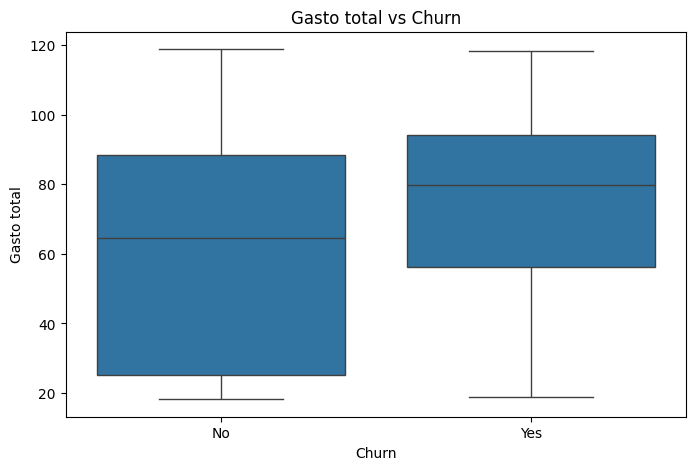

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='account_charges_monthly', data=data)

plt.title('Gasto total vs Churn')
plt.xlabel('Churn')
plt.ylabel('Gasto total')

plt.show()

## Soporte técnico VS Churn

In [72]:
data.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly'],
      dtype='str')

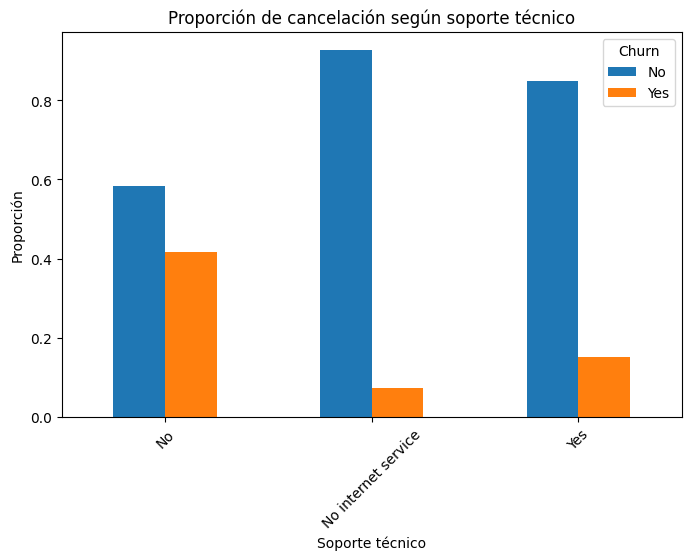

In [73]:
tabla_soporte_vs_churn = pd.crosstab(data['internet_techsupport'], data['churn'], normalize='index')

tabla_soporte_vs_churn.plot(kind='bar', figsize=(8,5))

plt.title('Proporción de cancelación según soporte técnico')
plt.xlabel('Soporte técnico')
plt.ylabel('Proporción')
plt.xticks(rotation=45)

plt.legend(title='Churn')

plt.show()

## Tipo de contrato VS Churn

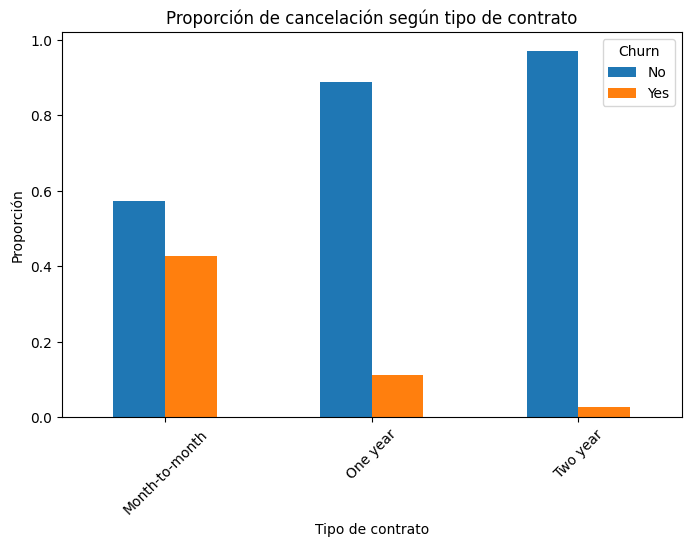

In [74]:
tabla_soporte_vs_churn = pd.crosstab(data['account_contract'], data['churn'], normalize='index')

tabla_soporte_vs_churn.plot(kind='bar', figsize=(8,5))

plt.title('Proporción de cancelación según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Proporción')
plt.xticks(rotation=45)

plt.legend(title='Churn')

plt.show()

# **Modelo predictivo**

## Separación de datos

In [75]:
# El train_test_split se realizó en la celda 18, desde antes del Encoding para evitar la fuga de datos.

## Creación de modelos

### **Regresión logística**

In [76]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_res)
y_pred_log = log_model.predict(X_test_scaled)

### **K-Nearest Neighbors (kNN)**

In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train_res)
y_pred_knn = knn.predict(X_test_scaled)

### **Neural Network**

In [78]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(100,),
                         max_iter=500,
                         random_state=42)

nn_model.fit(X_train_scaled, y_train_res)
y_pred_nn = nn_model.predict(X_test_scaled)

## Evaluación de modelos

In [79]:
from sklearn.metrics import classification_report

print('Regresión logística')
print(classification_report(y_test, y_pred_log))

print('kNN')
print(classification_report(y_test, y_pred_knn))

print('Neural Network')
print(classification_report(y_test, y_pred_nn))

Regresión logística
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1294
           1       0.53      0.76      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.76      0.73      1761
weighted avg       0.80      0.76      0.77      1761

kNN
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      1294
           1       0.47      0.72      0.57       467

    accuracy                           0.71      1761
   macro avg       0.67      0.71      0.67      1761
weighted avg       0.77      0.71      0.72      1761

Neural Network
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1294
           1       0.52      0.55      0.54       467

    accuracy                           0.75      1761
   macro avg       0.68      0.69      0.68      1761
weighted avg       0.75      0.75  

## Tabla de métricas

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'kNN', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nn)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nn)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.760931,0.534431,0.764454,0.629075
1,kNN,0.706417,0.465565,0.723769,0.566639
2,Neural Network,0.748438,0.524390,0.552463,0.538060


El modelo que ha predicho mejor churn fue el de **Regresión logística.** Este modelo fue el mejor evaluado tanto en precisión y exactitud, así como en el score de F1. Para el tipo de análisis de churn de clientes, los modelos lineales generalmente sirven mejor, pues permiten estimar la relación entre variables de manera sencilla y directa, identificando patrones y tendencias que indiquen cuando el cliente está a punto de abandonar la empresa. Esto se debe a su capacidad de predecir cambios en la variable dependiente (churn) basandose en variables independientes (factores que influyen en el comportamiento del cliente).

***

El modelo de regresión logística mostró el mejor equilibrio entre precisión y capacidad de generalización, sin evidencias claras de overfitting.

Por otro lado, el modelo KNN presentó un rendimiento inferior, lo que sugiere posibles limitaciones para capturar los patrones del dataset.

La red neuronal obtuvo un desempeño similar en exactitud, pero con menor capacidad para detectar clientes que cancelan el servicio, lo que podría indicar un ligero underfitting debido al tamaño del conjunto de datos.

## Matriz de confusión

### Regresión logística

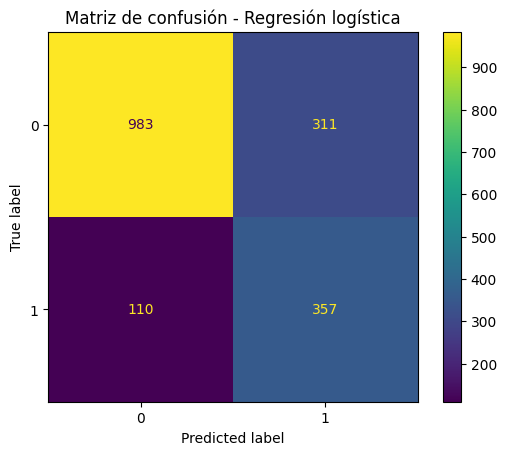

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title('Matriz de confusión - Regresión logística')
plt.show()

- Verdaderos negativos : 983. Acertó que 993 clientes no cancelarían.
- Verdaderos positivos: 357. Detectó 357 casos que sí cancelarían.
- Falsos positivos: 311. Predijo que 311 cancelarían pero no cancelaron.
- Falsos negativos: 110. Predijo que 110 no cancelarían pero sí cancelaron.*

### kNN

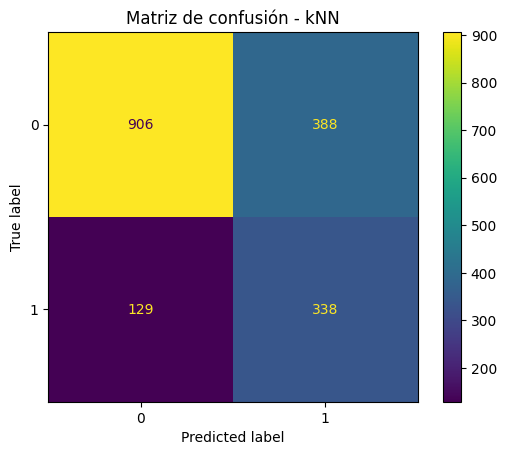

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title('Matriz de confusión - kNN')
plt.show()

- Verdaderos negativos : 906. Acertó que 906 clientes no cancelarían.
- Verdaderos positivos: 338. Detectó 338 casos que sí cancelarían.
- Falsos positivos: 388. Predijo que 388 cancelarían pero no cancelaron.
- Falsos negativos: 129. Predijo que 129 no cancelarían pero sí cancelaron. *

### Neural Network

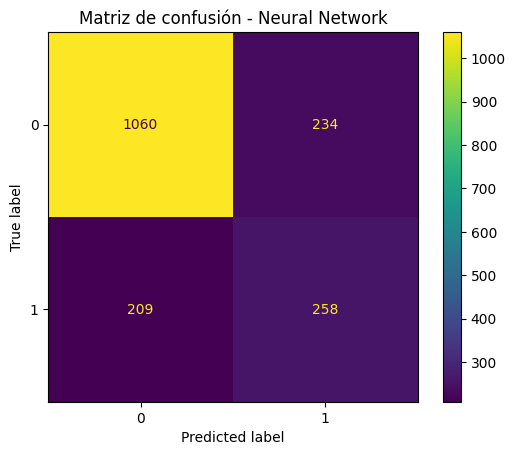

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title('Matriz de confusión - Neural Network')
plt.show()

- Verdaderos negativos : 1060. Acertó que 1060 clientes no cancelarían.
- Verdaderos positivos: 258. Detectó 258 casos que sí cancelarían.
- Falsos positivos: 234. Predijo que 234 cancelarían pero no cancelaron.
- Falsos negativos: 209. Predijo que 209 no cancelarían pero sí cancelaron. *

### Variables que influyen más Churn

In [84]:
import pandas as pd

coeficientes = pd.Series(
    log_model.coef_[0],
    index=X_train_encoded.columns
)

coeficientes.sort_values(ascending=False).head(10)

onehotencoder__internet_internetservice_Fiber optic      0.387174
onehotencoder__account_contract_Month-to-month           0.286475
onehotencoder__internet_streamingtv_Yes                  0.191277
onehotencoder__internet_streamingmovies_Yes              0.187045
onehotencoder__account_paperlessbilling_Yes              0.185701
onehotencoder__account_paymentmethod_Electronic check    0.146926
onehotencoder__phone_multiplelines_Yes                   0.130927
onehotencoder__internet_techsupport_No                   0.121089
onehotencoder__internet_onlinesecurity_No                0.120276
onehotencoder__internet_deviceprotection_Yes             0.095974
dtype: float64

### Variables que reducen Churn

In [85]:
coeficientes.sort_values(ascending=False).tail(10)

onehotencoder__internet_onlinebackup_No internet service       -0.108344
onehotencoder__internet_deviceprotection_No internet service   -0.108344
onehotencoder__internet_streamingtv_No internet service        -0.108344
onehotencoder__customer_dependents_Yes                         -0.113575
onehotencoder__phone_multiplelines_No                          -0.113612
onehotencoder__account_paymentmethod_Credit card (automatic)   -0.136149
onehotencoder__account_contract_Two year                       -0.315329
onehotencoder__internet_internetservice_DSL                    -0.331192
remainder__customer_tenure                                     -0.716878
remainder__account_charges_monthly                             -0.844118
dtype: float64

# **Interpretación y conclusiones**

## Análisis de la importancia de las variables

### Regresión logística

En Regresión logística cada variable tiene un coeficiente, los cuales indican: 
- positivo: aumento de la probabilidad de churn
- negativo: reduce la probabilidad de churn
- valor absoluto grande: variable de mayor importancia

In [ ]:
coeficiente_df = pd.DataFrame({
    'Variable': X_train_encoded.columns,
    'Coeficiente': log_model.coef_[0]
})

coeficiente_df = coeficiente_df.sort_values(by='Coeficiente', ascending=False)

display(coeficiente_df.head(10))

,Variable,Coeficiente
9,onehotencoder__internet_internetservice_Fiber ...,0.387174
29,onehotencoder__account_contract_Month-to-month,0.286475
25,onehotencoder__internet_streamingtv_Yes,0.191277
28,onehotencoder__internet_streamingmovies_Yes,0.187045
32,onehotencoder__account_paperlessbilling_Yes,0.185701
35,onehotencoder__account_paymentmethod_Electroni...,0.146926
7,onehotencoder__phone_multiplelines_Yes,0.130927
20,onehotencoder__internet_techsupport_No,0.121089
11,onehotencoder__internet_onlinesecurity_No,0.120276
19,onehotencoder__internet_deviceprotection_Yes,0.095974


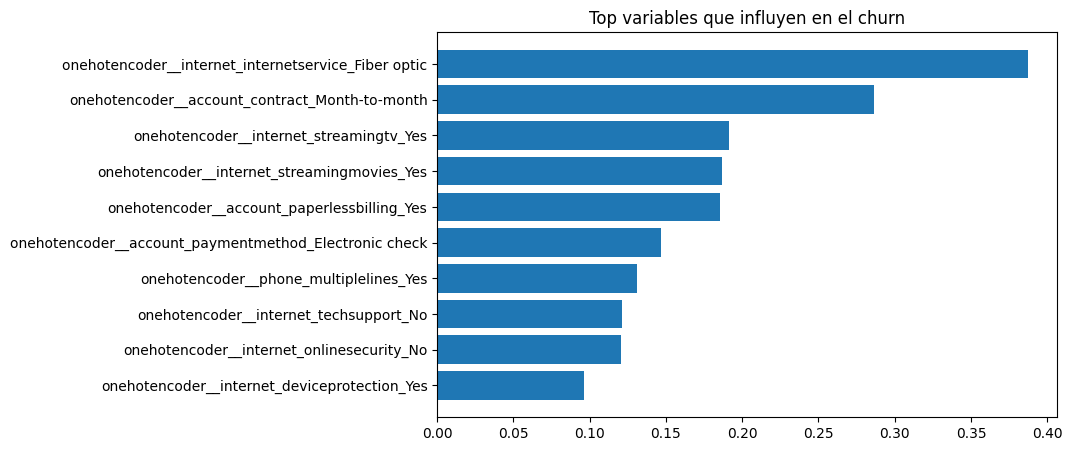

In [ ]:
import matplotlib.pyplot as plt

top = coeficiente_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top['Variable'], top['Coeficiente'])
plt.title('Top variables que influyen en el churn')
plt.gca().invert_yaxis()
plt.show()

### kNN

Como kNN no es un modelo paramétrico, no aprende coeficientes; en su lugar clasifica según la distancia entre puntos, siendo las variables más importantes aquellas que influyen en esa distancia.

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(knn, X_test_scaled, y_test, n_repeats=10, random_state=42)

importancias_knn = pd.DataFrame({
    'Variable': X_train_encoded.columns,
    'Importancia': result.importances_mean
})

importancias_knn = importancias_knn.sort_values(by='Importancia', ascending=False)

importancias_knn.head(10)

,Variable,Importancia
30,onehotencoder__account_contract_One year,0.016752
29,onehotencoder__account_contract_Month-to-month,0.011755
37,remainder__customer_tenure,0.011357
36,onehotencoder__account_paymentmethod_Mailed check,0.010960
31,onehotencoder__account_contract_Two year,0.010846
34,onehotencoder__account_paymentmethod_Credit ca...,0.008972
2,onehotencoder__customer_partner_Yes,0.007609
35,onehotencoder__account_paymentmethod_Electroni...,0.007212
17,onehotencoder__internet_deviceprotection_No,0.007098
38,remainder__account_charges_monthly,0.007098


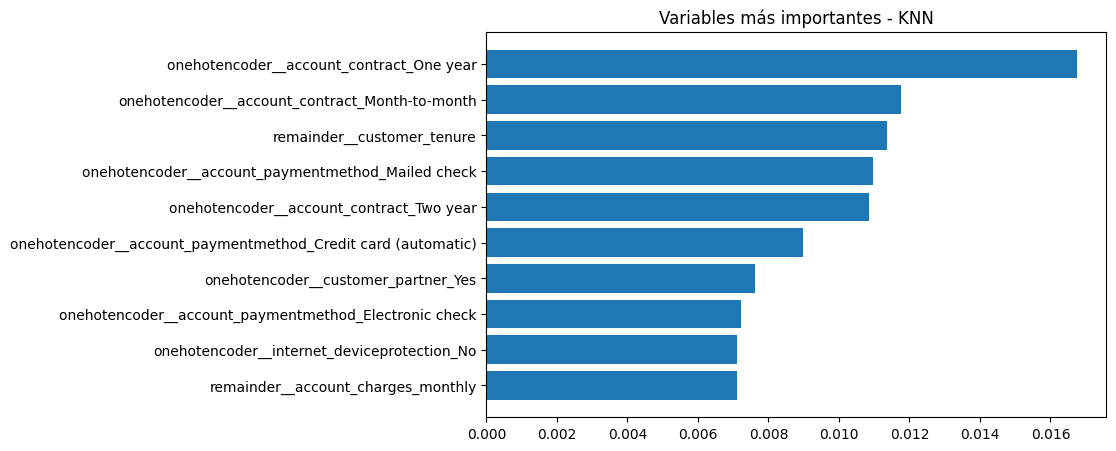

In [ ]:
top_knn = importancias_knn.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_knn['Variable'], top_knn['Importancia'])
plt.title('Variables más importantes - KNN')
plt.gca().invert_yaxis()
plt.show()

### Redes neuronales

In [ ]:
from sklearn.inspection import permutation_importance

result_nn = permutation_importance(nn_model, X_test_scaled, y_test, n_repeats=10, random_state=42)

importancias_nn = pd.DataFrame({
    'Variable': X_test_encoded.columns,
    'Importancia': result_nn.importances_mean
})

importancias_nn = importancias_nn.sort_values(by='Importancia', ascending=False)

importancias_nn.head(10)

,Variable,Importancia
36,onehotencoder__account_paymentmethod_Mailed check,0.033504
20,onehotencoder__internet_techsupport_No,0.032198
37,remainder__customer_tenure,0.025440
21,onehotencoder__internet_techsupport_No interne...,0.020784
34,onehotencoder__account_paymentmethod_Credit ca...,0.017149
31,onehotencoder__account_contract_Two year,0.016354
30,onehotencoder__account_contract_One year,0.016014
24,onehotencoder__internet_streamingtv_No interne...,0.014480
5,onehotencoder__phone_multiplelines_No,0.014424
29,onehotencoder__account_contract_Month-to-month,0.013288


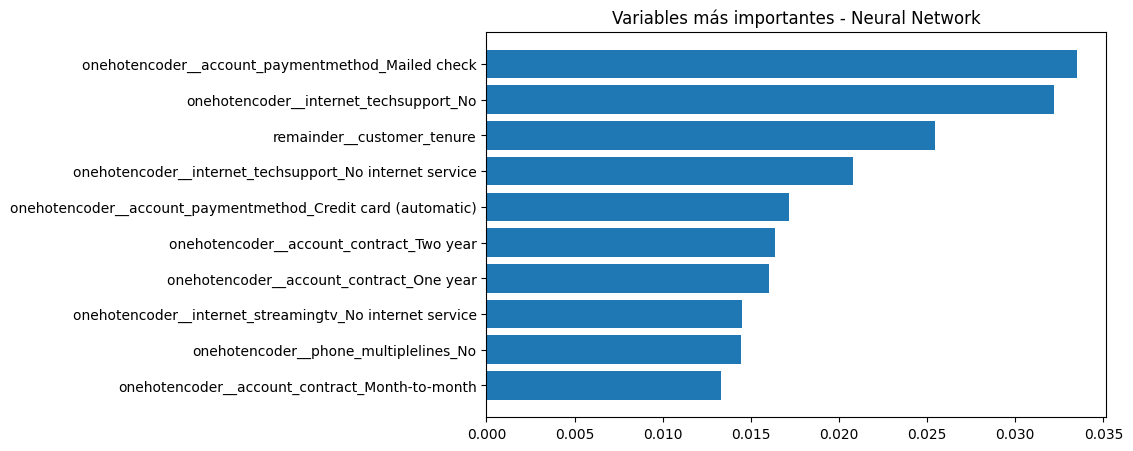

In [ ]:
top_nn = importancias_nn.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_nn['Variable'], top_nn['Importancia'])
plt.title('Variables más importantes - Neural Network')
plt.gca().invert_yaxis()
plt.show()

# **Informe final TelecomX - segunda parte**

# **Objetivo del análisis**

La identificación temprana de clientes con riesgo de abandono permite a la empresa **implementar estrategias de retención**, reduciendo pérdidas económicas y mejorando el nivel de satisfacción del cliente. 

Debido a esto, el objetivo de este proyecto consistió en desarrollar modelos de aprendizaje automático capaces de predecir la **probabilidad de cancelación de clientes (churn)** en la empresa TelecomX.

***

# **Preparación de los datos**

Para elaborar los modelos de predicción se llevaron a cabo los siguientes pasos:

1. Descarga del archivo csv previamente tratado y limpiado en la etapa anterior del proyecto.

2. Eliminación de variables irrelevantes como 'customerid' (es sólo un identificador del cliente), 'daily_accounts' y 'account_charges_total' (para evitar redundancia pues se correlacionan altamente entre ellas).

3. Transormación de variables categóricas mediante One-Hot Encoding.

4. Codificación de la variable objetivo (churn) usando LabelEncoder.

5. División (75/25) del dataset en conjunto de entrenamiento (train) y conjunto de prueba (test) mediante *train_test_split*.

6. Balanceo de clases utilizando SMOTE, debido a que el dataset presentó un desbalance considerable (73% no churn, 27% churn).

7. Escalado de variables numéricas para mejorar el rendimiento de modelos sensibles a escala como Regresión logística, kNN y Redes neuronales.

***

# **Modelos utilizados**

Se entrenaron 3 modelos de clasificación: **Regresión logística, K-Nearest Neighbors (kNN) y Red Neuronal (MLPClassifier)**. 

Estos modelos fueron evaluados utilizando métricas como: **Accuracy, Precision, Recall, F1-score y Matriz de correlación**.

***

# **Resultados de los modelos**

## **Regresión Logística**

- Accuracy aproximada: 0.76

- F1-score churn ≈ 0.63

El modelo mostró un buen equilibrio entre precisión y recall, especialmente para detectar clientes que cancelan el servicio. Además ofrece alta interpretabilidad, permitiendo identificar directamente qué variables influyen en la cancelación.

## **KNN**

- Accuracy aproximada: 0.71

- F1-score churn ≈ 0.57


El modelo KNN presentó un desempeño ligeramente inferior, con menor capacidad para identificar correctamente clientes que cancelan.Esto puede deberse a que el modelo depende fuertemente de la proximidad entre observaciones, lo cual puede verse afectado por la alta dimensionalidad generada por el One-Hot Encoding.

## **Red Neuronal**

- Accuracy aproximada: 0.75

- F1-score churn ≈ 0.54

Aunque tiene buena capacidad predictiva, su interpretabilidad es menor, por lo que se utilizó Permutation Importance para analizar la relevancia de las variables.

***

# **Variables importantes para la predicción**

El análisis de importancia de variables permitió identificar los factores más influyentes en la cancelación de clientes.

Entre las variables más relevantes se encuentran:

- Tiempo de permanencia (Tenure): Los clientes con menor tiempo en la compañía presentan mayor probabilidad de cancelar el servicio, esto sugiere que el riesgo de churn es más alto en los primeros meses de relación con el cliente.

- Cargos mensuales (Monthly Charges): Los clientes con mayores cargos mensuales tienden a cancelar con mayor frecuencia, posiblemente debido a percepciones de alto costo o baja relación costo-beneficio.

- Tipo de contrato: Los clientes con contratos mensuales presentan mayor tasa de cancelación en comparación con aquellos con contratos de largo plazo. Esto indica que los contratos largos generan mayor entrega a la empresa.

- Soporte técnico (Tech Support): Los clientes que no cuentan con soporte técnico tienen mayor probabilidad de cancelar el servicio, lo que sugiere que este es un factor importante en la satisfacción del cliente.

- Tipo de servicio de internet: Algunos tipos de servicio de internet, especialmente aquellos con mayores costos o problemas de calidad, también mostraron relación con mayores tasas de cancelación.

***

# **Interpretación general**

Los resultados indican que la cancelación de clientes está principalmente relacionada con:

- Nivel de compromiso contractual
- Costo del servicio
- Experiencia con los servicios técnicos
- Antigüedad del cliente

**Los clientes nuevos y con contratos más flexibles presentan mayor riesgo de abandono.**

***

# **Estrategias de retención**

Con base en los hallazgos del análisis, se proponen las siguientes estrategias:

- Programas de fidelización para nuevos clientes: Debido a que el churn es mayor entre clientes con poco tiempo en la empresa, se recomienda ofrecer descuentos, implementar programas de bienvenida y seguimiento personalizado durante los primeros meses.

- Optimización de precios: De la misma manera, hay clientes con mayor tasa de cancelación que también tienen cargos mensuales elevados, por lo que se podrían implementar planes de pago más accesibles, promociones o paquetes de servicios y planes personalizados según las necesidades del cliente.

- Fortalecimiento de soporte técnico: Un factor relevante para churn es la falta de servicio al cliente, por lo que mejorar la disponibilidad y calidad del soporte técnico podría reducir significativamente la cancelación. Se podría ofrecer soporte técnico en más planes y mejorar la atención y experiencia al usuario en este ámbito.

- Incentivar contratos a largo plazo: Como los contratos de mayor duración reducen el churn podrían implementarse descuentos por contratos anuales o beneficios adicionales por permanencia.

***

# **Conclusiones**

- El análisis predictivo permitió identificar patrones claros asociados a la cancelación de clientes en TelecomX.

- Entre los factores más influyentes destacan el tiempo de permanencia del cliente, el tipo de contrato, los cargos mensuales y la disponibilidad de soporte técnico.

- El modelo de regresión logística mostró el mejor equilibrio entre rendimiento e interpretabilidad, lo que lo convierte en una herramienta útil para implementar estrategias de retención basadas en datos.

- La aplicación de estas estrategias podría contribuir significativamente a reducir la tasa de cancelación y mejorar la retención de clientes.